# Getting Started with **PennyLane**
### Quantum Computing Education Series by Trinexis 2026

---

**Welcome!** This notebook is a *self-contained, run-from-top-to-bottom* introduction to
[PennyLane](https://pennylane.ai/), one of the leading open-source frameworks for
quantum computing and quantum machine learning, developed by **Xanadu**.

So far in this course we have built everything *by hand* with **NumPy**, state vectors,
operators, the Born rule, the Bloch sphere, density matrices. That was deliberate: it
builds genuine physical intuition. Now we meet a **production framework** that automates
all of that book-keeping, so you can focus on the *algorithm* rather than the *linear
algebra*.

###  What you will learn
1. The three building blocks of PennyLane: **device**, **quantum function**, and **QNode**.
2. How to write, draw, and run your first quantum circuit.
3. How PennyLane reports results, **expectation values**, **probabilities**, **states**, **samples**.
4. PennyLane's signature feature: **automatic differentiation** of quantum circuits (the *parameter-shift rule*).
5. **Entanglement** in a Bell state, the framework way.
6. A tiny **hybrid quantum–classical** optimisation, *"training a circuit like a neural network."*
7. A side-by-side **comparison with Qiskit**.
8. **Graded exercises** (★ to ★★★) with hidden solutions, so you can practise on your own.

### How to use this notebook
- Runs in **Google Colab** with no setup beyond the install cell below.
- Run cells **in order** with `Shift + Enter`.
- Read the comments, every code cell is documented.
- Try the exercises at the end *before* peeking at the solutions.

> **Tip:** In Colab, go to *Runtime → Run all* to execute everything once, then come back
> and experiment cell by cell.


## 0  Setup, installing and importing

The cell below makes sure **PennyLane** and **Qiskit** (used only for the comparison in
§8) are installed. On a fresh Colab runtime they are *not* preinstalled, so this may take
a minute the first time.

In a normal Colab notebook you could simply write:

```python
!pip install pennylane qiskit -q
```

We use a slightly safer version that only installs what is missing, so the cell is
harmless to re-run.


In [1]:
# --- Install dependencies only if they are missing ---------------------------
import importlib, subprocess, sys

for package in ["pennylane", "qiskit"]:
    if importlib.util.find_spec(package) is None:
        print(f"Installing {package} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package])
    else:
        print(f"{package} already available.")


Installing pennylane ...
Installing qiskit ...


In [2]:
# --- Core imports ------------------------------------------------------------
import numpy as np                      # ordinary NumPy (non-trainable arrays, plotting)
import matplotlib.pyplot as plt         # plotting

import pennylane as qml                 # the star of the show
from pennylane import numpy as pnp      # PennyLane's NumPy: arrays that can be differentiated

# Reproducibility: fix the random seed so sampled results match across runs.
np.random.seed(42)

print("PennyLane version :", qml.__version__)
import qiskit
print("Qiskit version    :", qiskit.__version__)


PennyLane version : 0.45.1
Qiskit version    : 2.5.0


> **Why two NumPys?** `import numpy as np` is the normal one. `from pennylane import numpy
> as pnp` is a thin wrapper that *remembers gradients*. We use **`pnp` for any parameter we
> want to optimise or differentiate**, and plain `np` for everything else (ranges, plotting).
> This distinction trips up many beginners, keep it in mind.


## 1  The big picture: three building blocks

Every PennyLane program is built from **three** pieces:

| Piece | What it is | Analogy |
|-------|------------|---------|
| **Device** | *Where* the circuit runs, a simulator or real hardware | The "computer" |
| **Quantum function** | A plain Python function containing **gates** and ending in a **measurement** | The "program" |
| **QNode** | Device + quantum function bound together into one callable object | The "executable" |

```
            ┌─────────────────────────────────────────┐
   inputs   │   QNode                                  │   classical
  (numbers) │   ┌───────────┐      ┌────────────────┐  │   numbers out
  ─────────▶│   │  gates    │ ───▶ │  measurement   │  │ ─────────────▶
            │   │ (circuit) │      │ (expval/probs) │  │
            │   └───────────┘      └────────────────┘  │
            │            runs on  →  DEVICE             │
            └─────────────────────────────────────────┘
```

The beauty of the **QNode** is that, from the outside, it behaves like an *ordinary Python
function*: numbers go in, numbers come out. That is exactly what lets us slot a quantum
circuit into classical optimisation and machine-learning loops later on.


## 2  Our first PennyLane quantum circuit

Let's build the simplest possible circuit: take a single qubit (which starts in state
$|0\rangle$), rotate it about the $x$-axis of the Bloch sphere by an angle $\theta$ using
the **`RX`** gate, and then measure the expectation value of the Pauli-$Z$ observable,
$\langle Z \rangle$.

Recall from our Bloch-sphere module that $RX(\theta)$ tilts the state vector, and that
$\langle Z\rangle = \cos\theta$ for this particular circuit.


In [3]:
# Step 1: choose a DEVICE, the default state-vector simulator with 1 qubit ("wire").
dev = qml.device("default.qubit", wires=1)

# Step 2: write a QUANTUM FUNCTION and bind it to the device with the @qml.qnode decorator.
@qml.qnode(dev)
def my_first_circuit(theta):
    qml.RX(theta, wires=0)            # rotate qubit 0 about the x-axis by angle theta
    return qml.expval(qml.PauliZ(0)) # measure <Z> on qubit 0

# Step 3: call it like any Python function.
for theta in [0.0, np.pi/2, np.pi]:
    print(f"theta = {theta:5.3f}  ->  <Z> = {my_first_circuit(theta): .4f}   (cos = {np.cos(theta): .4f})")


theta = 0.000  ->  <Z> =  1.0000   (cos =  1.0000)
theta = 1.571  ->  <Z> =  0.0000   (cos =  0.0000)
theta = 3.142  ->  <Z> = -1.0000   (cos = -1.0000)


The output matches $\langle Z\rangle = \cos\theta$ exactly:
- $\theta = 0$: state stays at $|0\rangle$, so $\langle Z\rangle = +1$.
- $\theta = \pi/2$: state lands on the equator, so $\langle Z\rangle = 0$.
- $\theta = \pi$: state flips to $|1\rangle$, so $\langle Z\rangle = -1$.

### Visualising the circuit
PennyLane can draw any QNode for you, as text, or as a matplotlib figure.


In [4]:
# Text drawing (great for quick checks and for printing in logs)
print(qml.draw(my_first_circuit)(theta=0.5))


0: ──RX(0.50)─┤  <Z>


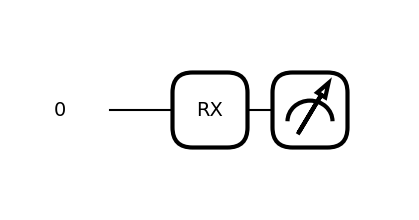

In [5]:
# Matplotlib drawing (nicer for slides). It returns (figure, axis).
fig, ax = qml.draw_mpl(my_first_circuit)(theta=0.5)
plt.show()


## 3  How PennyLane reports results

A measurement in our course meant *collapse to an eigenstate with a Born-rule probability*.
PennyLane lets you ask for several different "views" of the final state by changing the
**return statement** of the quantum function:

| Return | Meaning |
|--------|---------|
| `qml.expval(obs)` | Expectation value $\langle \text{obs}\rangle$ (a single number) |
| `qml.probs(wires=...)` | Born-rule probabilities of each basis outcome |
| `qml.state()` | The full complex state vector (simulator only) |
| `qml.counts()` / `qml.sample()` | Actual measurement *shots* (like a real device) |

Let's prepare the superposition $|+\rangle = \tfrac{1}{\sqrt2}(|0\rangle + |1\rangle)$ with a
**Hadamard** gate and inspect it four different ways.


In [6]:
dev1 = qml.device("default.qubit", wires=1)

# (a) Expectation value of Z on |+>  ->  0  (equator of the Bloch sphere)
@qml.qnode(dev1)
def expval_view():
    qml.Hadamard(wires=0)
    return qml.expval(qml.PauliZ(0))

# (b) Born-rule probabilities  ->  [0.5, 0.5]
@qml.qnode(dev1)
def probs_view():
    qml.Hadamard(wires=0)
    return qml.probs(wires=0)

# (c) Full state vector  ->  [0.707, 0.707]
@qml.qnode(dev1)
def state_view():
    qml.Hadamard(wires=0)
    return qml.state()

print("(a) <Z>            =", np.round(expval_view(), 4))
print("(b) probabilities  =", np.round(probs_view(), 4), " (P(0), P(1))")
print("(c) state vector   =", np.round(state_view(), 4))


(a) <Z>            = 0.0
(b) probabilities  = [0.5 0.5]  (P(0), P(1))
(c) state vector   = [0.7071+0.j 0.7071+0.j]


**Connecting to the Born rule.** Notice that the probabilities in (b) are exactly the
*squared magnitudes* of the amplitudes in (c): $|0.707|^2 = 0.5$. This is the unifying
thesis of the whole course, *probabilities are squared magnitudes of amplitudes*, now
delivered automatically by the framework.

### Finite shots: simulating a real device
A real quantum computer does give us the probabilities; it gives a finite number
of **shots** (individual measurement outcomes). We attach shots with the `@qml.set_shots`
transform and ask for `counts`.


In [7]:
dev_shots = qml.device("default.qubit", wires=1)

@qml.set_shots(shots=2000)          # take 2000 measurement shots
@qml.qnode(dev_shots)
def sampled_view():
    qml.Hadamard(wires=0)
    return qml.counts()             # how many 0s and how many 1s?

np.random.seed(42)                  # reproducible sampling
counts = sampled_view()
counts = {str(k): int(v) for k, v in counts.items()}   # tidy the output
print("Measured counts over 2000 shots:", counts)
print("Empirical P(0) =", round(counts.get('0', 0) / 2000, 3),
      "  P(1) =", round(counts.get('1', 0) / 2000, 3))


Measured counts over 2000 shots: {'0': 986, '1': 1014}
Empirical P(0) = 0.493   P(1) = 0.507


With 2000 shots the empirical frequencies are close to the ideal 0.5 / 0.5, but not
exact, that statistical noise is the price of working with a finite number of measurements
on real hardware.


## 4  "Write once, run anywhere"

A headline feature of PennyLane is that the **same circuit** runs on different backends -
simulators or real hardware, by changing **one line**: the device. Below we run the
*identical* quantum function on the pure-Python `default.qubit` simulator and on the fast
C++ `lightning.qubit` simulator, and confirm they agree.


In [8]:
def run_on(device_name):
    # Build and execute the same circuit on whichever device is named.
    dev = qml.device(device_name, wires=2)

    @qml.qnode(dev)
    def circuit():
        qml.Hadamard(wires=0)
        qml.CNOT(wires=[0, 1])
        return qml.probs(wires=[0, 1])

    return circuit()

# The ONLY thing that changes between these calls is the device string.
print("default.qubit   ->", np.round(run_on("default.qubit"), 3))

try:
    print("lightning.qubit ->", np.round(run_on("lightning.qubit"), 3))
except Exception as e:
    print("lightning.qubit not available here (that's fine):", type(e).__name__)


default.qubit   -> [0.5 0.  0.  0.5]
lightning.qubit -> [0.5 0.  0.  0.5]


Same circuit, same results, different engine under the hood. In a real project you
would swap in a hardware device (for example IBM, Amazon Braket, or Xanadu) the same way -
**no change to the circuit logic itself.** That portability is one of PennyLane's biggest
selling points.


## 5  PennyLane's power: differentiable quantum circuits

This is what truly sets PennyLane apart. It can compute the **gradient** of a circuit's
output *with respect to its gate parameters*, automatically, and in a way that works
**even on real quantum hardware**, using a result called the **parameter-shift rule**.

Why does this matter? Because gradients are the engine of all modern optimisation and
machine learning. If you can differentiate a quantum circuit, you can *train* it.

Our circuit returns $\langle Z\rangle = \cos\theta$, so calculus tells us the exact
gradient is $-\sin\theta$. Let's see PennyLane reproduce that with **zero hand-derived
calculus**.


In [9]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def f(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))      #  = cos(theta)

# qml.grad returns a NEW function that computes the derivative.
df = qml.grad(f)

# Evaluate at theta = pi/4. Trainable inputs use pnp arrays with requires_grad=True.
theta0 = pnp.array(np.pi / 4, requires_grad=True)
print("f(pi/4)      =", round(float(f(theta0)),       5), "  (cos pi/4 =", round(np.cos(np.pi/4), 5), ")")
print("f'(pi/4)     =", round(float(df(theta0)),      5), "  (-sin pi/4=", round(-np.sin(np.pi/4), 5), ")")


f(pi/4)      = 0.70711   (cos pi/4 = 0.70711 )
f'(pi/4)     = -0.70711   (-sin pi/4= -0.70711 )


### Visual proof across the whole range
Let's plot the circuit output and its PennyLane-computed gradient against the exact
analytic curves $\cos\theta$ and $-\sin\theta$.


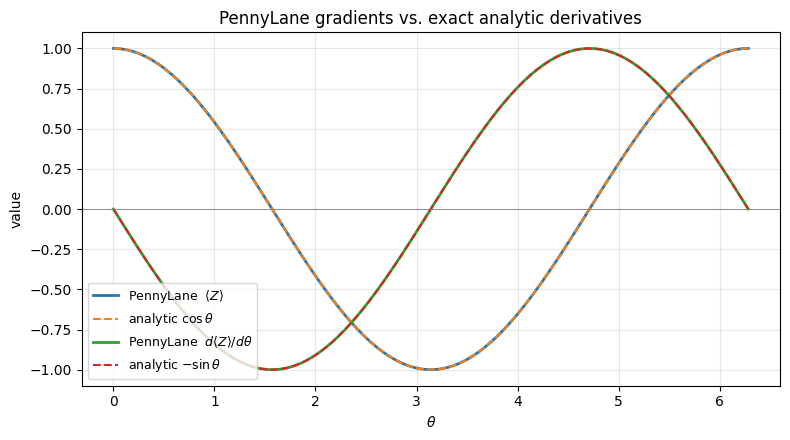

In [10]:
thetas = np.linspace(0, 2*np.pi, 100)

# Circuit value and PennyLane gradient at each angle.
values    = [float(f(pnp.array(t)))                       for t in thetas]
gradients = [float(df(pnp.array(t, requires_grad=True)))  for t in thetas]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(thetas, values,    label=r"PennyLane  $\langle Z\rangle$", lw=2)
ax.plot(thetas, np.cos(thetas), '--', label=r"analytic $\cos\theta$")
ax.plot(thetas, gradients, label=r"PennyLane  $d\langle Z\rangle/d\theta$", lw=2)
ax.plot(thetas, -np.sin(thetas), '--', label=r"analytic $-\sin\theta$")
ax.axhline(0, color='gray', lw=0.6)
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("value")
ax.set_title("PennyLane gradients vs. exact analytic derivatives")
ax.legend(loc="lower left", fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The PennyLane curves sit **exactly** on top of the analytic ones. We never wrote a
single derivative by hand.

### Where do those gradients come from? The parameter-shift rule
For a rotation gate, the exact derivative can be obtained by evaluating the **same circuit
at two shifted parameter values**:

$$\frac{\partial \langle Z\rangle}{\partial \theta}
   = \frac{1}{2}\Big[\, f\!\left(\theta + \tfrac{\pi}{2}\right), f\!\left(\theta, \tfrac{\pi}{2}\right)\Big].$$

This is remarkable: it needs only *circuit evaluations*, so it works on **real hardware**
where you cannot "look inside" to do classical back-propagation. Let's verify it by hand.


In [11]:
t = 1.0                                  # any test angle
shift = np.pi / 2

manual   = (float(f(pnp.array(t + shift))), float(f(pnp.array(t, shift)))) / 2
autograd = float(df(pnp.array(t, requires_grad=True)))
analytic = -np.sin(t)

print(f"parameter-shift (by hand) : {manual: .6f}")
print(f"qml.grad (automatic)      : {autograd: .6f}")
print(f"analytic  -sin(theta)     : {analytic: .6f}")
print("\nAll three agree -> the parameter-shift rule gives EXACT gradients.")


parameter-shift (by hand) : -0.841471
qml.grad (automatic)      : -0.841471
analytic  -sin(theta)     : -0.841471

All three agree -> the parameter-shift rule gives EXACT gradients.


## 6  Entanglement, the framework way: the Bell state

In our entanglement module we built the Bell state
$|\Phi^+\rangle = \tfrac{1}{\sqrt2}(|00\rangle + |11\rangle)$ by hand. Here it is in three
lines of PennyLane: a Hadamard to create superposition, then a CNOT to entangle.


In [12]:
dev2 = qml.device("default.qubit", wires=2)

@qml.qnode(dev2)
def bell_state():
    qml.Hadamard(wires=0)       # qubit 0 -> (|0> + |1>)/sqrt(2)
    qml.CNOT(wires=[0, 1])      # entangle: copy qubit 0 onto qubit 1
    return qml.state()

@qml.qnode(dev2)
def bell_probs():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

print("State vector (|00>, |01>, |10>, |11>):")
print(np.round(bell_state(), 3))
print("\nProbabilities:")
for label, p in zip(["00", "01", "10", "11"], bell_probs()):
    print(f"  P(|{label}>) = {p:.3f}")


State vector (|00>, |01>, |10>, |11>):
[0.707+0.j 0.   +0.j 0.   +0.j 0.707+0.j]

Probabilities:
  P(|00>) = 0.500
  P(|01>) = 0.000
  P(|10>) = 0.000
  P(|11>) = 0.500


/tmp/ipykernel_1131/2638863620.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


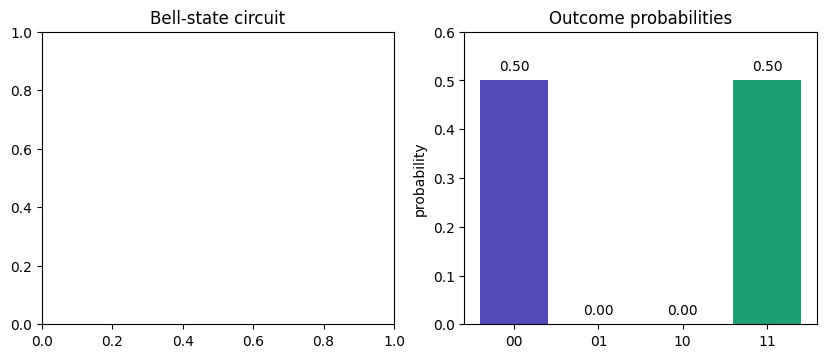

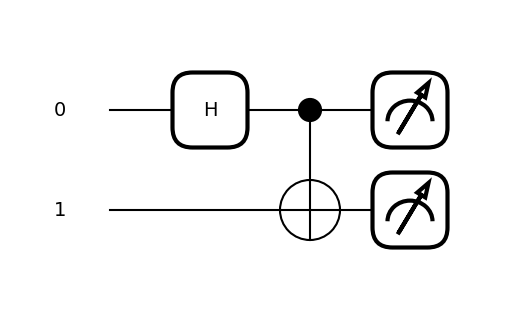

In [21]:
# Draw the circuit and bar-chart the probabilities side by side.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))

qml.draw_mpl(bell_state, ax=axes[0])()           # draw onto the left axis
axes[0].set_title("Bell-state circuit")

labels = ["00", "01", "10", "11"]
axes[1].bar(labels, bell_probs(), color=["#534AB7", "#bbbbbb", "#bbbbbb", "#1D9E75"])
axes[1].set_ylim(0, 0.6); axes[1].set_ylabel("probability")
axes[1].set_title("Outcome probabilities")
for i, p in enumerate(bell_probs()):
    axes[1].text(i, p + 0.02, f"{p:.2f}", ha="center")
plt.tight_layout(); plt.show()


**The signature of entanglement:** only $|00\rangle$ and $|11\rangle$ ever occur, each
with probability $0.5$. The outcomes $|01\rangle$ and $|10\rangle$ *never* happen. The two
qubits are perfectly correlated, measure one and you instantly know the other, yet
neither qubit has a definite value on its own. This is exactly the *indistinguishable
alternatives interfere* idea, now scaled up to two particles.


## 7  Putting it together: training a circuit like a neural network

Now we combine everything: a **parameterised circuit** + **gradients** + a **classical
optimiser**, all in one loop. This *hybrid quantum–classical* pattern is the basis of
**Variational Quantum Algorithms (VQAs)** and **quantum machine learning**.

**Goal:** start the qubit at $|0\rangle$ and find the rotation angle $\theta$ that *minimises*
$\langle Z\rangle$. We know the answer is $\theta = \pi$ (which sends $|0\rangle \to |1\rangle$,
giving $\langle Z\rangle = -1$), but we'll let the optimiser discover it from gradients alone.


In [14]:
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def cost(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))    # we want to push this DOWN to -1

# Start far from the answer.
theta = pnp.array(0.10, requires_grad=True)

# A classical gradient-descent optimiser (PennyLane ships several).
opt = qml.GradientDescentOptimizer(stepsize=0.3)

history = []
for step in range(60):
    theta, cost_val = opt.step_and_cost(cost, theta)   # one gradient-descent update
    history.append(float(cost_val))

print(f"Optimised theta = {float(theta):.4f}   (target = pi = {np.pi:.4f})")
print(f"Final <Z>       = {float(cost(theta)):.4f}   (target = -1)")


Optimised theta = 3.1416   (target = pi = 3.1416)
Final <Z>       = -1.0000   (target = -1)


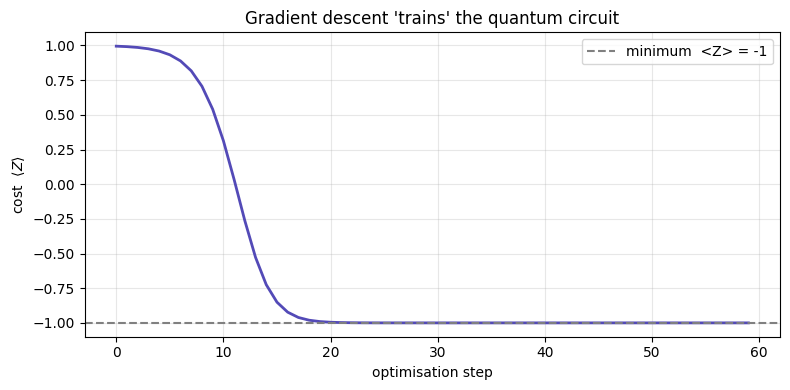

In [15]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history, lw=2, color="#534AB7")
ax.axhline(-1, ls="--", color="gray", label="minimum  <Z> = -1")
ax.set_xlabel("optimisation step"); ax.set_ylabel(r"cost  $\langle Z\rangle$")
ax.set_title("Gradient descent 'trains' the quantum circuit")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


The cost slides smoothly down to $-1$ as the optimiser rotates the qubit from
$|0\rangle$ to $|1\rangle$, **exactly the loop you would write to train a neural network**,
except one "layer" is a quantum circuit. Swap in a richer parameterised circuit and a real
dataset, and you have quantum machine learning.


## 8  PennyLane vs. Qiskit

Both **PennyLane** (Xanadu) and **Qiskit** (IBM) are mature, open-source, Python-first
quantum frameworks. They overlap heavily but were designed with different priorities.
Below we build the *same Bell state* in each so you can see the syntax side by side.


In [16]:
# ---------- PennyLane version (recap) ----------
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def bell_pennylane():
    qml.Hadamard(wires=0)
    qml.CNOT(wires=[0, 1])
    return qml.probs(wires=[0, 1])

pl_probs = bell_pennylane()
print("PennyLane Bell probabilities:")
for label, p in zip(["00", "01", "10", "11"], pl_probs):
    print(f"  P(|{label}>) = {p:.3f}")


PennyLane Bell probabilities:
  P(|00>) = 0.500
  P(|01>) = 0.000
  P(|10>) = 0.000
  P(|11>) = 0.500


In [17]:
# ---------- Qiskit version (same physics, different API) ----------
# We use Qiskit's built-in Statevector so no extra simulator backend is needed.
try:
    from qiskit import QuantumCircuit
    from qiskit.quantum_info import Statevector

    qc = QuantumCircuit(2)
    qc.h(0)            # Hadamard on qubit 0
    qc.cx(0, 1)        # CNOT (control 0, target 1)

    sv = Statevector(qc)
    qk_probs = sv.probabilities_dict()

    print("Qiskit circuit:")
    print(qc.draw(output="text"))
    print("\nQiskit Bell probabilities:")
    for label, p in sorted(qk_probs.items()):
        print(f"  P(|{label}>) = {p:.3f}")
except Exception as e:
    print("Qiskit not available in this runtime:", type(e).__name__, e)


Qiskit circuit:
     ┌───┐     
q_0: ┤ H ├──■──
     └───┘┌─┴─┐
q_1: ─────┤ X ├
          └───┘

Qiskit Bell probabilities:
  P(|00>) = 0.500
  P(|11>) = 0.500


Both frameworks produce the same physics: $P(00)=P(11)=0.5$. The *structure* of the
code is similar, pick qubits, apply H and CNOT, read out probabilities, but the idioms
differ. (Aside: Qiskit labels basis states in **little-endian** order, the reverse of
PennyLane's, which matters for non-symmetric states. The Bell state is symmetric, so you
don't see it here.)

### How they compare

| Aspect | **PennyLane** (Xanadu) | **Qiskit** (IBM) |
|--------|------------------------|------------------|
| Primary focus | Quantum **machine learning** & differentiable programming | **General-purpose** quantum computing |
| Hardware stance | **Hardware-agnostic**, IBM, Google, Braket, Xanadu, … | Optimised for **IBM Quantum** hardware |
| Built-in gradients | **Yes**, parameter-shift rule, works on hardware | Not a core feature |
| ML integration | **Native**, a QNode is a PyTorch / TensorFlow / JAX layer | Possible, needs more glue code |
| Visualisation | Code-first; matplotlib circuit drawings | Rich drawings + web-based **Circuit Composer** GUI |
| Learning curve | Steeper; rewards an ML mindset | Often **gentler** for first-time gate circuits |
| Community / reach | Strong QML & research community, large tutorial library | **Largest** overall user base |

**Rule of thumb.** Reach for **PennyLane** when your work involves *optimisation, gradients,
or machine learning*. Reach for **Qiskit** when you are *targeting IBM hardware* or want a
GUI-friendly on-ramp for absolute beginners. They are complementary, and many researchers
use both. (PennyLane can even run circuits *on* IBM hardware via a plugin.)


## 9.  Exercises

Work through these in order. Each has a **★ difficulty rating** and a **hidden solution** -
try it yourself first, then click *Solution* to check. Edit and run the scaffold cell
directly.


### ★ Exercise 1, Prepare $|+\rangle$ and measure $\langle X\rangle$

The state $|+\rangle$ is the "+1" eigenstate of the Pauli-$X$ observable, so measuring
$\langle X\rangle$ on it should give **exactly +1** (this is the $S_x$-up state from our
Stern–Gerlach module!).

We have already set the observable to **`qml.PauliX`** for you. **Your task:** add the
**one gate** (a Hadamard) that prepares $|+\rangle$, then run and confirm the result is **+1**.
(Before you add it, the cell measures $\langle X\rangle$ on $|0\rangle$, which is **0**, your
signal that the gate is still missing.)


In [18]:
dev_ex1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex1)
def plus_circuit():
    # >>> YOUR CODE HERE <<<  (add one gate: a Hadamard on wire 0)
    return qml.expval(qml.PauliX(0))   # observable already set for you

print("<X> on your state =", round(float(plus_circuit()), 4), " (target: +1)")


<X> on your state = 0.0  (target: +1)


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
dev_ex1 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex1)
def plus_circuit():
    qml.Hadamard(wires=0)              # prepare |+>
    return qml.expval(qml.PauliX(0))   # measure <X>  ->  +1

print("<X> on your state =", round(float(plus_circuit()), 4))
```
</details>


### ★★ Exercise 2, Sweep an angle and plot $\langle Z\rangle$

Build a circuit `ry_circuit(theta)` that applies **`RY(theta)`** to qubit 0 and returns
$\langle Z\rangle$. For this circuit $\langle Z\rangle = \cos\theta$.

**Task:** evaluate it over $\theta \in [0, 2\pi]$ and plot the curve. At which angle does
$\langle Z\rangle$ first cross **zero** (i.e. the qubit reaches the Bloch-sphere equator)?


In [19]:
dev_ex2 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex2)
def ry_circuit(theta):
    # >>> YOUR CODE HERE <<<  (apply RY(theta) to wire 0)
    return qml.expval(qml.PauliZ(0))

angles = np.linspace(0, 2*np.pi, 100)
# >>> YOUR CODE HERE <<<  (compute <Z> at each angle and plot)


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
dev_ex2 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex2)
def ry_circuit(theta):
    qml.RY(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

angles = np.linspace(0, 2*np.pi, 100)
vals = [float(ry_circuit(a)) for a in angles]

plt.figure(figsize=(8, 4))
plt.plot(angles, vals, lw=2)
plt.axhline(0, color="gray", ls="--")
plt.axvline(np.pi/2, color="red", ls=":", label=r"$\theta=\pi/2$ (equator)")
plt.xlabel(r"$\theta$"); plt.ylabel(r"$\langle Z\rangle$")
plt.legend(); plt.grid(alpha=0.3); plt.show()

# <Z> = cos(theta) first crosses zero at theta = pi/2.
```
</details>


### ★★★ Exercise 3, Train a qubit to hit a target value

Use the hybrid optimisation loop from §7, but with a **custom cost**. We want the qubit's
$\langle Z\rangle$ to equal a *target* value $m^\* = 0.5$ (not the extreme $-1$).

A natural cost to **minimise** is the squared error
$\;C(\theta) = \big(\langle Z\rangle, 0.5\big)^2$, which is zero when we hit the target.

**Task:** write `target_cost(theta)` returning that squared error, then run gradient
descent for ~80 steps from $\theta_0 = 0.1$. What final $\theta$ do you get, and does
$\langle Z\rangle$ reach $0.5$? *(Hint: since $\langle Z\rangle = \cos\theta$, the exact
answer is $\theta = \arccos 0.5 = \pi/3 \approx 1.047$.)*


In [20]:
dev_ex3 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex3)
def z_value(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

def target_cost(theta):
    # >>> YOUR CODE HERE <<<  (return (z_value(theta), 0.5)**2)
    return 0.0 * theta   # placeholder so the cell runs; replace me

# >>> YOUR CODE HERE <<<  (gradient-descent loop starting from theta0 = 0.1)


<details>
<summary><b>Solution (click to reveal)</b></summary>

```python
dev_ex3 = qml.device("default.qubit", wires=1)

@qml.qnode(dev_ex3)
def z_value(theta):
    qml.RX(theta, wires=0)
    return qml.expval(qml.PauliZ(0))

def target_cost(theta):
    return (z_value(theta), 0.5) ** 2     # squared error vs target 0.5

theta = pnp.array(0.1, requires_grad=True)
opt = qml.GradientDescentOptimizer(stepsize=0.4)

for _ in range(80):
    theta, c = opt.step_and_cost(target_cost, theta)

print("Optimised theta =", round(float(theta), 4), " (target arccos(0.5) = pi/3 =", round(np.pi/3, 4), ")")
print("Final <Z>       =", round(float(z_value(theta)), 4), " (target 0.5)")
```
</details>


## 10  Recap & where to go next

**What we covered**
- PennyLane = **device** + **quantum function** + **QNode**; a QNode behaves like an ordinary function.
- Four ways to read out a circuit: **expval**, **probs**, **state**, **counts/samples**, and how `probs` are just squared amplitudes (the Born rule).
- **Write once, run anywhere**: change the device string, not the circuit.
- The distinctive feature, **automatic differentiation** via the **parameter-shift rule**, exact and hardware-compatible.
- **Entanglement** in a Bell state, and a full **hybrid quantum–classical training loop**.
- A fair **comparison with Qiskit**.

**Keep practising**
- Build a 3-qubit **GHZ state** $\tfrac{1}{\sqrt2}(|000\rangle + |111\rangle)$, extend the Bell pattern.
- Add a **second parameter** to the trainable circuit and watch the optimiser tune both.
- Explore PennyLane's [demos](https://pennylane.ai/qml/demonstrations/) on QML and chemistry.

**Official resources**
- Documentation: <https://docs.pennylane.ai/>
- Tutorials & demos: <https://pennylane.ai/qml/>
- Community forum: <https://discuss.pennylane.ai/>

---
*Quantum Computing Education Series by Trinexis 2026*
